In [2]:
import numpy as np #I use numpy for most things. It plays well with other things, and I find it avoids data type conflicts well
from numpy import genfromtxt #This will help read in a data file as a numpy array
from scipy.optimize import curve_fit #This will help us do nonlinear least squares fitting.

import matplotlib.pyplot as plt #This allows you to plot things using the Matplotlib library. 

# Two Slit Interference, One Photon at a Time (Quantum)

## Laser

### Shoulder Plot

Text(0.5, 0.01, 'Caption: ')

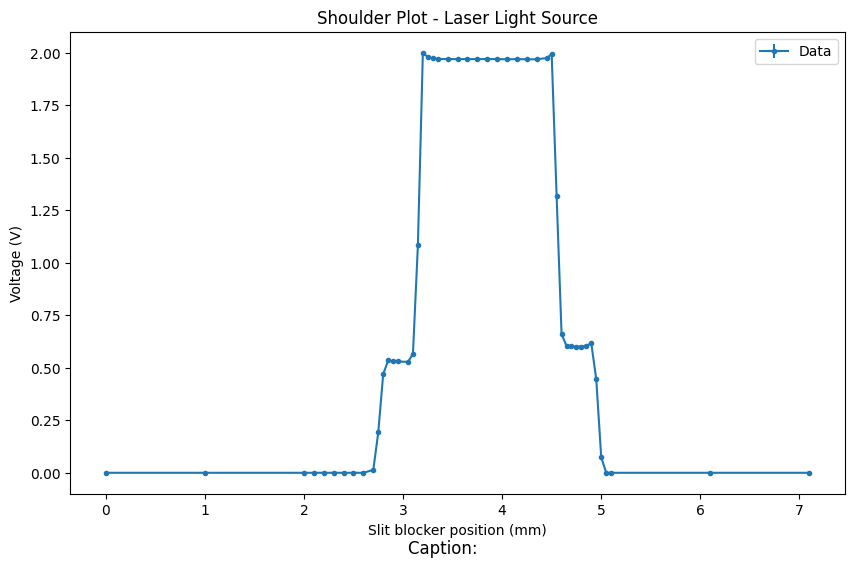

In [23]:
#Import "ShoulderPlotv2.txt"
data = genfromtxt("ShoulderPlotv2.txt", delimiter=' ', skip_header=0)

# Convert micrometer readings to mm after loading data with genfromtxt and delimiter=' '
# Column 0 = rotation, Column 1 = marks

rotation = data[:, 0]  # in 0.50 mm units
marks = data[:, 1]  # in 0.01 mm units

x_mm = (rotation * 0.50) + (marks * 0.01)  
V = data[:, 2] - 0.005
x_mm_error = 0.005
V_error = 0.001

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(x_mm, V, xerr = x_mm_error, yerr = V_error, fmt='.-', label="Data")
plt.legend()
plt.xlabel('Slit blocker position (mm)')
plt.ylabel('Voltage (V)')
plt.title('Shoulder Plot - Laser Light Source')
plt.figtext(0.5, 0.01, "Caption: ", wrap=True, horizontalalignment='center', fontsize=12)


### One Slit Open

Reduced Chi Squared = 5.780
I0 = 0.546 ± 0.001
A = 0.684 ± 0.001
xc = 2.427 ± 0.003


Text(0.5, 0.01, 'Caption: ')

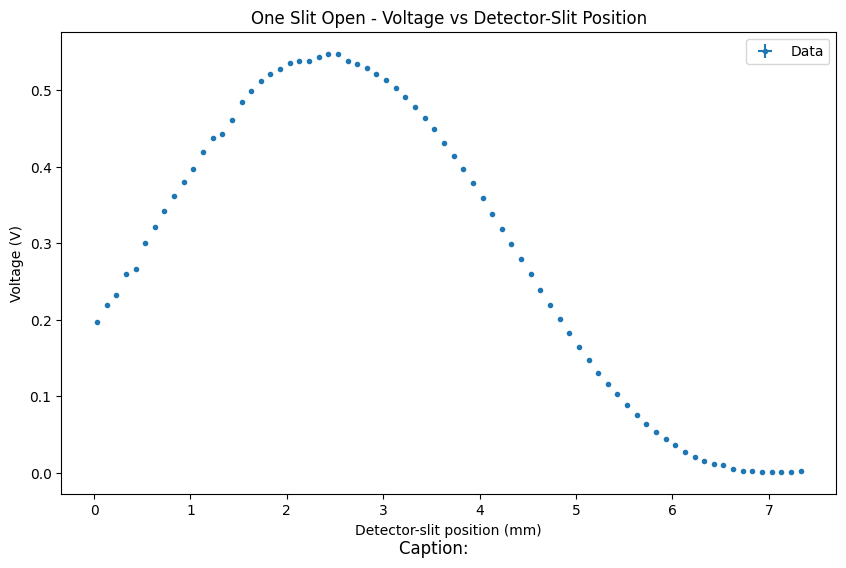

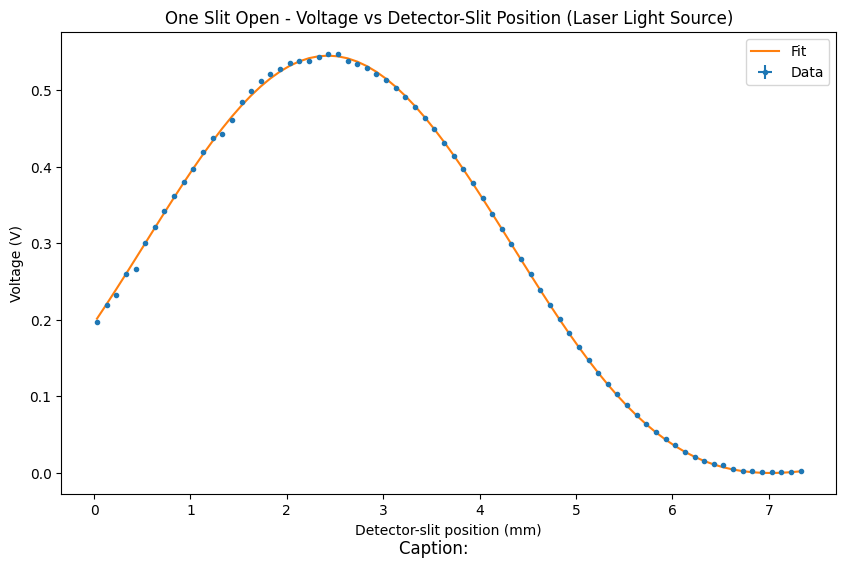

In [24]:
#KEY REMOVE FOR STUDENTS
#Import "OneSlitOpen.txt"
data = genfromtxt("OneSlitOpen.txt", delimiter=' ', skip_header=0)

# Convert micrometer readings to mm after loading data with genfromtxt and delimiter=' '
# Column 0 = rotation, Column 1 = marks

rotation = data[:, 0]  # in 0.50 mm units
marks = data[:, 1]  # in 0.01 mm units

x_mm = (rotation * 0.50) + (marks * 0.01)  
V = data[:, 2] - 0.005
x_mm_error = 0.005
V_error = 0.001


#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(x_mm, V, xerr = x_mm_error, yerr = V_error, fmt='.', label="Data")
plt.legend()
plt.xlabel('Detector-slit position (mm)')
plt.ylabel('Voltage (V)')
plt.title('One Slit Open - Voltage vs Detector-Slit Position')
plt.figtext(0.5, 0.01, "Caption: ", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Fraunhofer(x, I0, A, xc):
    I = I0 * (np.sin(A * (x - xc)) / (A * (x - xc)))**2
    return I

#Preliminarily Fit the Data
guess_I0 = 0.5
guess_A = 1
guess_xc = 2.5



guess=np.array([guess_I0, guess_A, guess_xc])
uw_fits,uw_covs=curve_fit(Fraunhofer, x_mm, V, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dI/dx
I0, A, xc = uw_fits
with np.errstate(divide='ignore', invalid='ignore'):
    dI_dx = ((2 * I0 * A) / ((A * (x_mm - xc))**3)) * np.sin(A * (x_mm - xc)) * ((A * (x_mm - xc) * np.cos(A * (x_mm - xc)) - np.sin(A * (x_mm - xc)))) 
    dI_dx = np.nan_to_num(dI_dx, nan=0.0) # Derivative is zero at the peak

#Calculate total error
sigmas= np.sqrt(V_error**2 + (dI_dx * x_mm_error)**2)

#Perform weighted fit
fits, covs=curve_fit(Fraunhofer, x_mm, V, p0=guess, sigma=sigmas, maxfev=10000)
stds=np.sqrt(np.diag(covs))


#Calculate reduced chi squared
Red_chi_sq_I1= 1.0/(x_mm.size-3.0) * np.sum((V - Fraunhofer(x_mm, *fits))**2/sigmas**2)
print(f'Reduced Chi Squared = {Red_chi_sq_I1:.3f}')
print(f"I0 = {fits[0]:.3f} ± {stds[0]:.3f}")
print(f"A = {fits[1]:.3f} ± {stds[1]:.3f}")
print(f"xc = {fits[2]:.3f} ± {stds[2]:.3f}")
                 

#Plot the fit with the data!
fit_V = Fraunhofer(x_mm, *fits)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(x_mm, V, xerr=x_mm_error, yerr=V_error, fmt='.', label="Data")
plt.plot(x_mm, fit_V, '-', label="Fit")
plt.legend()
plt.xlabel('Detector-slit position (mm)')
plt.ylabel('Voltage (V)')
plt.title('One Slit Open - Voltage vs Detector-Slit Position (Laser Light Source)')
plt.figtext(0.5, 0.01, "Caption: ", wrap=True, horizontalalignment='center', fontsize=12)


### Other Slit Open

Reduced Chi Squared = 1.651
I0 = 0.628 ± 0.0003
A = 0.691 ± 0.0004
xc = 3.455 ± 0.001


Text(0.5, 0.01, 'Caption: ')

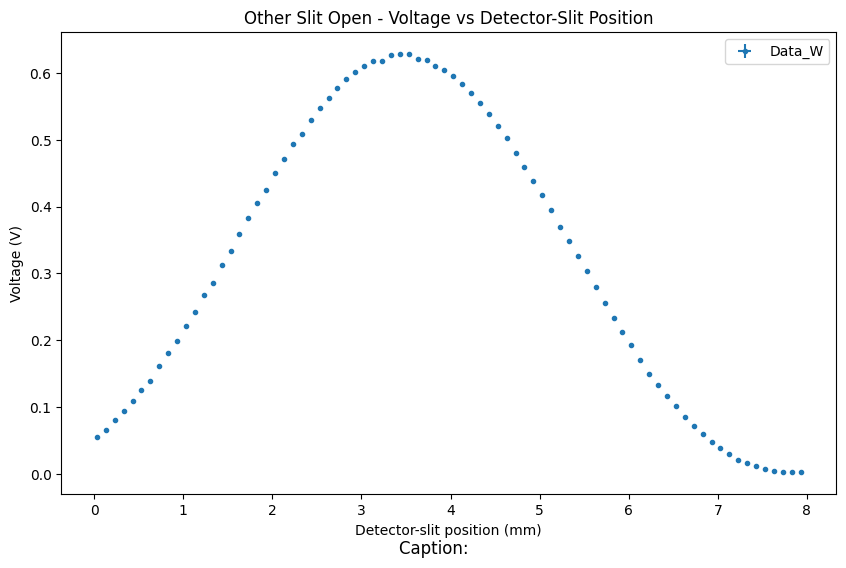

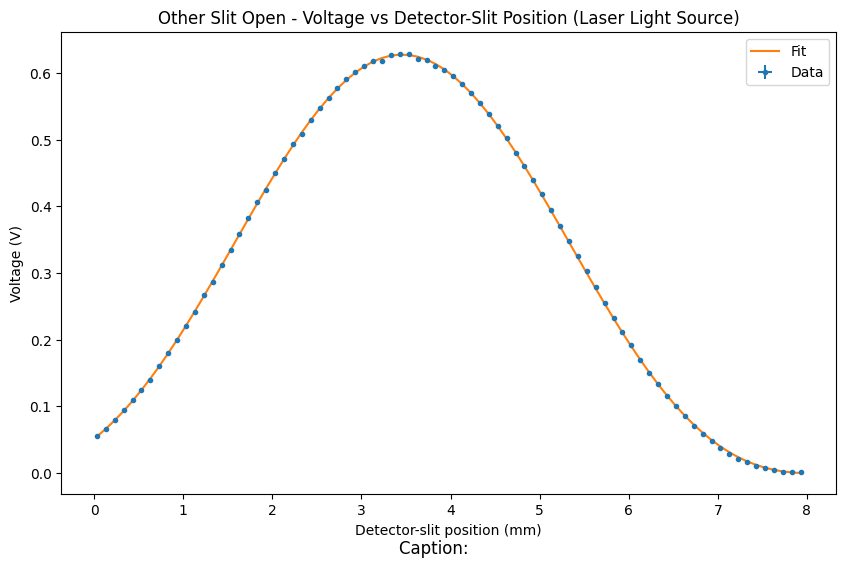

In [3]:
#KEY REMOVE FOR STUDENTS
#Import "OtherSlitOpen.txt"
data = genfromtxt("OtherSlitOpen.txt", delimiter=' ', skip_header=0)

# Convert micrometer readings to mm after loading data with genfromtxt and delimiter=' '
# Column 0 = rotation, Column 1 = marks

rotation = data[:, 0]  # in 0.50 mm units
marks = data[:, 1]  # in 0.01 mm units

x_mm = (rotation * 0.50) + (marks * 0.01)  
V = data[:, 2] - 0.005
x_mm_error = 0.005
V_error = 0.001


#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(x_mm, V, xerr = x_mm_error, yerr = V_error, fmt='.', label="Data_W")
plt.legend()
plt.xlabel('Detector-slit position (mm)')
plt.ylabel('Voltage (V)')
plt.title('Other Slit Open - Voltage vs Detector-Slit Position')
plt.figtext(0.5, 0.01, "Caption: ", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Fraunhofer(x, I0, A, xc):
    I = I0 * (np.sin(A * (x - xc)) / (A * (x - xc)))**2
    return I

#Preliminarily Fit the Data
guess_I0 = 0.5
guess_A = 0.684
guess_xc = 2.5



guess=np.array([guess_I0, guess_A, guess_xc])
uw_fits,uw_covs=curve_fit(Fraunhofer, x_mm, V, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dI/dx
I0, A, xc = uw_fits
dI_dx = ((2 * I0 * A) / ((A * (x_mm - xc))**3)) * np.sin(A * (x_mm - xc)) * ((A * (x_mm - xc) * np.cos(A * (x_mm - xc)) - np.sin(A * (x_mm - xc))))

#Calculate total error
sigmas= np.sqrt(V_error**2 + (dI_dx * x_mm_error)**2)

#Perform weighted fit
fits, covs=curve_fit(Fraunhofer, x_mm, V, p0=guess, sigma=sigmas, maxfev=10000)
stds=np.sqrt(np.diag(covs))


#Calculate reduced chi squared
Red_chi_sq_I1= 1.0/(x_mm.size-3.0) * np.sum((V - Fraunhofer(x_mm, *fits))**2/sigmas**2)
print(f'Reduced Chi Squared = {Red_chi_sq_I1:.3f}')
print(f"I0 = {fits[0]:.3f} ± {stds[0]:.4f}")
print(f"A = {fits[1]:.3f} ± {stds[1]:.4f}")
print(f"xc = {fits[2]:.3f} ± {stds[2]:.3f}")
                 

#Plot the fit with the data!
fit_V = Fraunhofer(x_mm, *fits)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(x_mm, V, xerr=x_mm_error, yerr=V_error, fmt='.', label="Data")
plt.plot(x_mm, fit_V, '-', label="Fit")
plt.legend()
plt.xlabel('Detector-slit position (mm)')
plt.ylabel('Voltage (V)')
plt.title('Other Slit Open - Voltage vs Detector-Slit Position (Laser Light Source)')
plt.figtext(0.5, 0.01, "Caption: ", wrap=True, horizontalalignment='center', fontsize=12)


### Both Slits Open

Reduced Chi Squared = 147.902
I0 = 2.195 ± 0.021
A = 0.679 ± 0.006
B = 3.877 ± 0.005
xc = 2.943 ± 0.002


Text(0.5, 0.01, 'Caption: ')

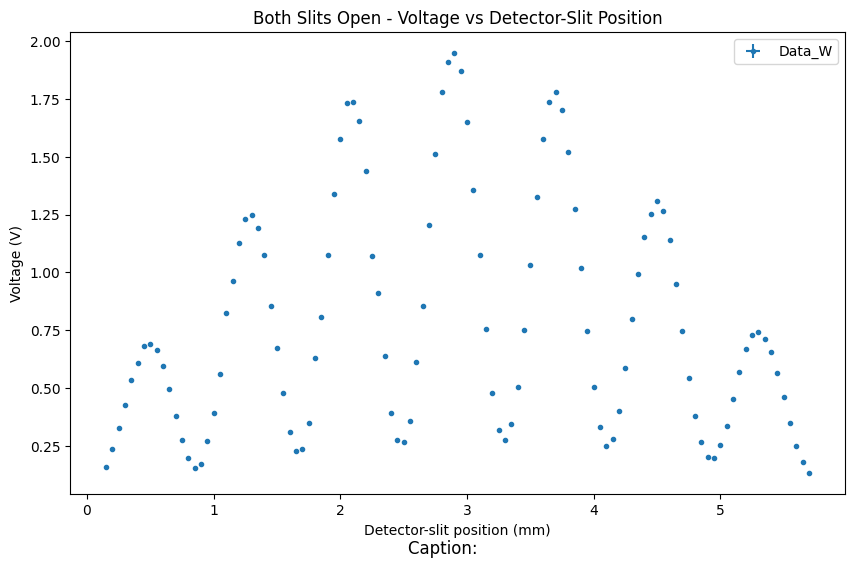

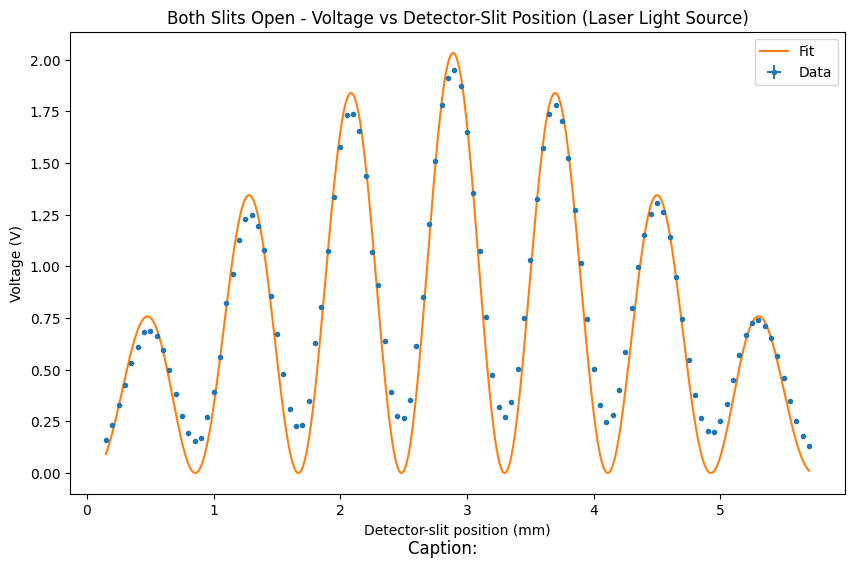

In [7]:
#KEY REMOVE FOR STUDENTS
#Import "BothSlitsOpen.txt"
data = genfromtxt("BothSlitsOpen.txt", delimiter=' ', skip_header=0)

# Convert micrometer readings to mm after loading data with genfromtxt and delimiter=' '
# Column 0 = rotation, Column 1 = marks

rotation = data[:, 0]  # in 0.50 mm units
marks = data[:, 1]  # in 0.01 mm units

x_mm = (rotation * 0.50) + (marks * 0.01)  
V = data[:, 2] - 0.005
x_mm_error = 0.005
V_error = 0.001

x_mm_range = x_mm[3:115]
V_range = V[3:115]


#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(x_mm_range, V_range, xerr = x_mm_error, yerr = V_error, fmt='.', label="Data_W")
plt.legend()
plt.xlabel('Detector-slit position (mm)')
plt.ylabel('Voltage (V)')
plt.title('Both Slits Open - Voltage vs Detector-Slit Position')
plt.figtext(0.5, 0.01, "Caption: ", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Fraunhofer(x, I0, A, B, xc):
    # 'epsilon' prevents division by zero
    epsilon = 1e-12
    I = I0 * (np.sin(A * (x - xc + epsilon)) / (A * (x - xc + epsilon)))**2 * (np.cos(B * (x - xc + epsilon)))**2 # + C
    return I

#Preliminarily Fit the Data
guess_I0 = 2
guess_A = 0.688
guess_B = 4
guess_xc = 3.0
#guess_C = 0.005



guess=np.array([guess_I0, guess_A, guess_B, guess_xc])
uw_fits,uw_covs=curve_fit(Fraunhofer, x_mm_range, V_range, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dI/dx
I0, A, B, xc = uw_fits
epsilon = 1e-12

for i in range(10):
    I0, A, B, xc = fits
    dI_dx = (2 * I0 * A * np.sin(A * (x_mm_range - xc + epsilon)) * 
             (A * (x_mm_range - xc + epsilon) * np.cos(A * (x_mm_range - xc + epsilon)) - 
              np.sin(A * (x_mm_range - xc + epsilon))) / 
             (A * (x_mm_range - xc + epsilon))**3) * np.cos(B * (x_mm_range - xc + epsilon))**2 + \
             I0 * (np.sin(A * (x_mm_range - xc + epsilon)) / 
             (A * (x_mm_range - xc + epsilon)))**2 * \
             (-2 * B * np.sin(B * (x_mm_range - xc + epsilon)) * np.cos(B * (x_mm_range - xc + epsilon)))
    
    sigmas = np.sqrt(V_error**2 + (dI_dx * x_mm_error)**2)
    fits, covs = curve_fit(Fraunhofer, x_mm_range, V_range, p0=fits, sigma=sigmas, maxfev=10000)
#dI_dx = (2 * I0 * A * np.sin(A * (x_mm_range - xc + epsilon)) * (A * (x_mm_range - xc + epsilon) * np.cos(A * (x_mm_range - xc + epsilon)) - np.sin(A * (x_mm_range - xc + epsilon))) / (A * (x_mm_range - xc + epsilon))**3) * np.cos(B * (x_mm_range - xc + epsilon))**2 + I0 * (np.sin(A * (x_mm_range - xc + epsilon)) / (A * (x_mm_range - xc + epsilon)))**2 * (-2 * B * np.sin(B * (x_mm_range - xc + epsilon)) * np.cos(B * (x_mm_range - xc + epsilon)))

#Calculate total error
sigmas= np.sqrt(V_error**2 + (dI_dx * x_mm_error)**2)

#Perform weighted fit
fits, covs=curve_fit(Fraunhofer, x_mm_range, V_range, p0=guess, sigma=sigmas, maxfev=10000)
stds=np.sqrt(np.diag(covs))


#Calculate reduced chi squared
Red_chi_sq= 1.0/(x_mm_range.size-4.0) * np.sum((V_range - Fraunhofer(x_mm_range, *fits))**2/sigmas**2)
print(f'Reduced Chi Squared = {Red_chi_sq:.3f}')
print(f"I0 = {fits[0]:.3f} ± {stds[0]:.3f}")
print(f"A = {fits[1]:.3f} ± {stds[1]:.3f}")
print(f"B = {fits[2]:.3f} ± {stds[2]:.3f}")
print(f"xc = {fits[3]:.3f} ± {stds[3]:.3f}")
# print(f"C = {fits[4]:.3f} ± {stds[4]:.3f}")

                 

#Plot the fit with the data!
x_smooth = np.linspace(x_mm_range.min(), x_mm_range.max(), 1000)
fit_V_smooth = Fraunhofer(x_smooth, *fits)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(x_mm_range, V_range, xerr=x_mm_error, yerr=V_error, fmt='.', label="Data")
plt.plot(x_smooth, Fraunhofer(x_smooth, *uw_fits), '-', label="Fit")
plt.legend()
plt.xlabel('Detector-slit position (mm)')
plt.ylabel('Voltage (V)')
plt.title('Both Slits Open - Voltage vs Detector-Slit Position (Laser Light Source)')
plt.figtext(0.5, 0.01, "Caption: ", wrap=True, horizontalalignment='center', fontsize=12)


## Light bulb

### Elbow Plot

C:\Users\ricky\AppData\Local\Temp\ipykernel_51508\1588831049.py:16: RuntimeWarning: divide by zero encountered in log
  count_rate_log = np.log(count_rate)
C:\Users\ricky\AppData\Local\Temp\ipykernel_51508\1588831049.py:17: RuntimeWarning: invalid value encountered in divide
  count_rate_log_error = count_rate_error / (np.log(10) * count_rate)


Text(0.5, 0.01, 'Caption: ')

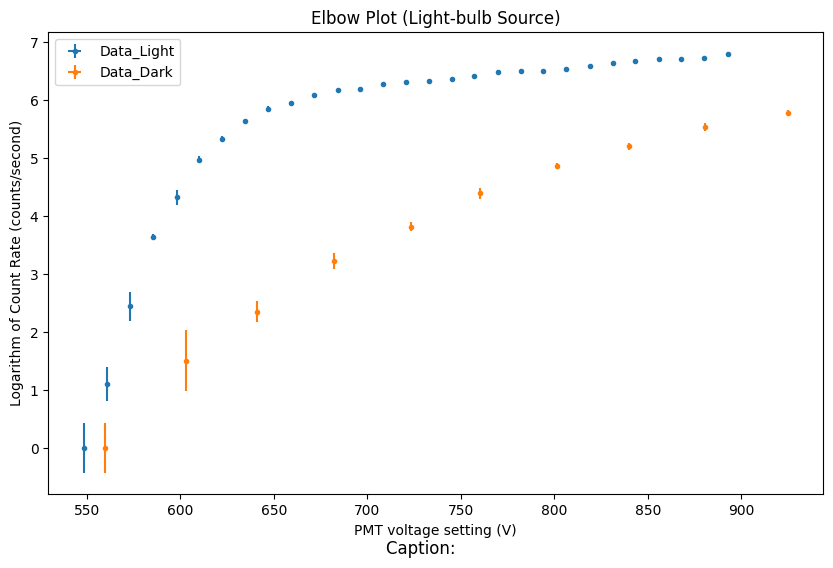

In [27]:
#KEY REMOVE FOR STUDENTS
#Import "ShoulderPlotLightRate.txt"
data = genfromtxt("ElbowPlotLightRate.txt", delimiter=' ', skip_header=0)
data1 = genfromtxt("ElbowPlotDarkRate.txt", delimiter=' ', skip_header=0)

V = data[:, 0]
count_rate = data[:, 2]
V_error = data[:, 1]
count_rate_error = data[:, 3]

V1 = data1[:, 0]
count_rate1 = data1[:, 2]
V1_error = data1[:, 1]
count_rate1_error = data1[:, 3]

count_rate_log = np.log(count_rate)
count_rate_log_error = count_rate_error / (np.log(10) * count_rate)
count_rate1_log = np.log(count_rate1)
count_rate1_log_error = count_rate1_error / (np.log(10) * count_rate1)

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(V, count_rate_log, xerr = V_error, yerr = count_rate_log_error, fmt='.', label="Data_Light")
plt.errorbar(V1, count_rate1_log, xerr = V1_error, yerr = count_rate1_log_error, fmt='.', label="Data_Dark")
plt.legend()
plt.xlabel('PMT voltage setting (V)')
plt.ylabel('Logarithm of Count Rate (counts/second)')
plt.title('Elbow Plot (Light-bulb Source)')
plt.figtext(0.5, 0.01, "Caption: ", wrap=True, horizontalalignment='center', fontsize=12)



### Shoulder Plot

Text(0.5, 0.01, 'Caption: ')

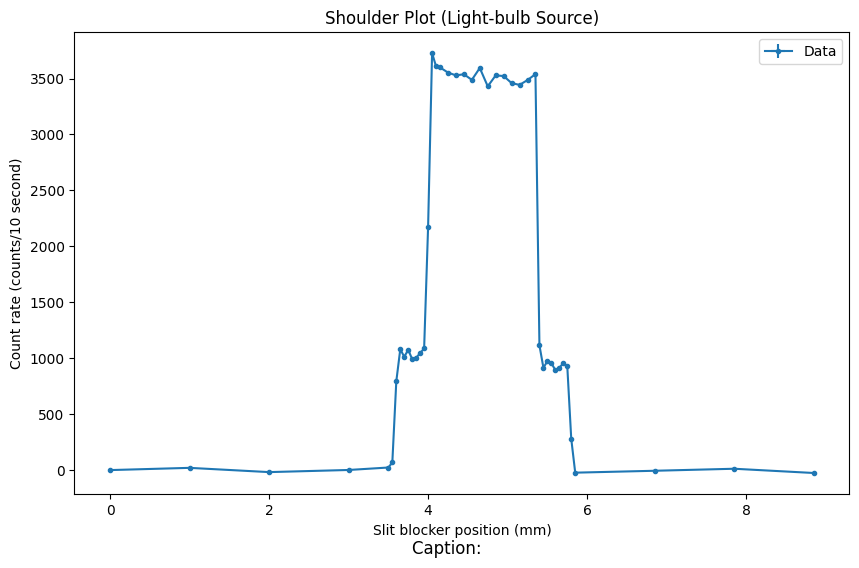

In [28]:
#Import "ShoulderPlotPhoton.txt"
data = genfromtxt("ShoulderPlotPhoton.txt", delimiter=' ', skip_header=0)

# Convert micrometer readings to mm after loading data with genfromtxt and delimiter=' '
# Column 0 = rotation, Column 1 = marks

rotation = data[:, 0]  # in 0.50 mm units
marks = data[:, 1]  # in 0.01 mm units

x_mm = (rotation * 0.50) + (marks * 0.01)  
V = data[:, 2] - 152
x_mm_error = 0.005
V_error = 0.001

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(x_mm, V, xerr = x_mm_error, yerr = V_error, fmt='.-', label="Data")
plt.legend()
plt.xlabel('Slit blocker position (mm)')
plt.ylabel('Count rate (counts/10 second)')
plt.title('Shoulder Plot (Light-bulb Source)')
plt.figtext(0.5, 0.01, "Caption: ", wrap=True, horizontalalignment='center', fontsize=12)


### One Slit

Reduced Chi Squared = 1.948
I0 = 1092.365 ± 9.322
A = -0.819 ± 0.004
xc = 3.171 ± 0.009


Text(0.5, 0.01, 'Caption: ')

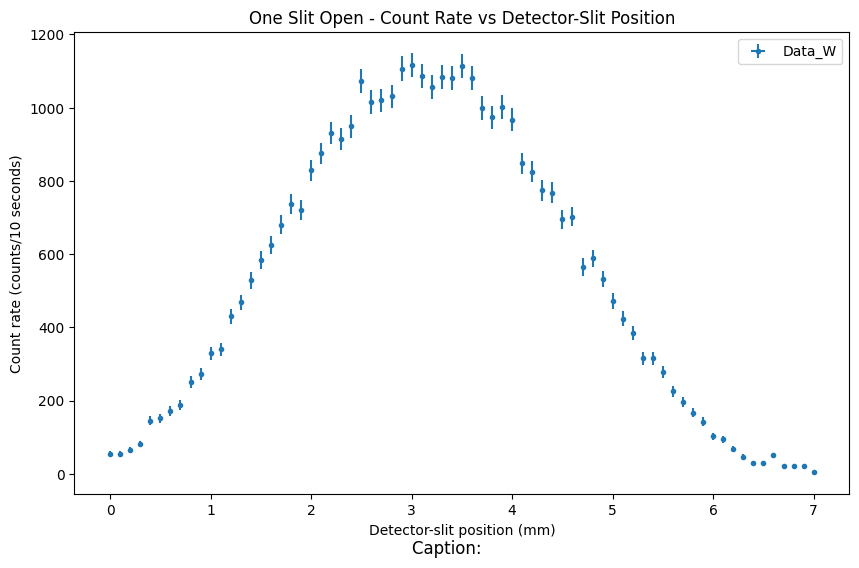

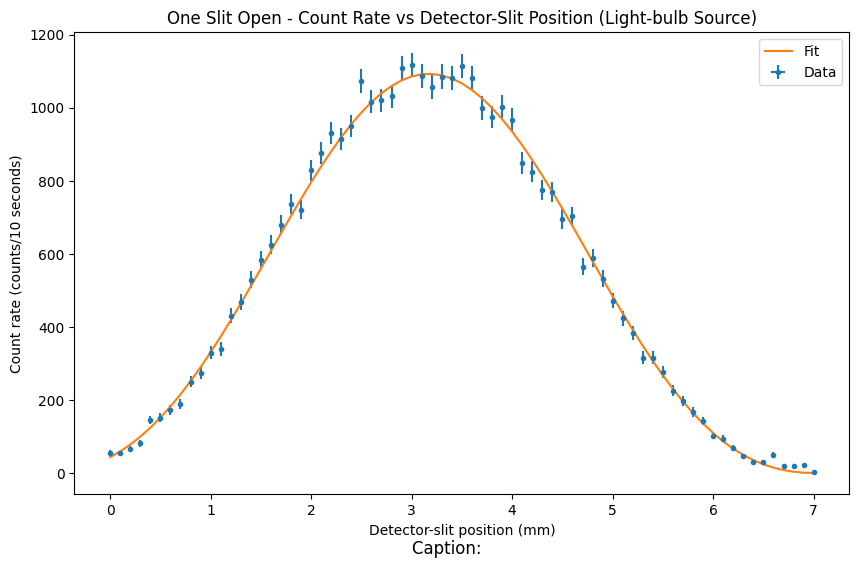

In [29]:
#KEY REMOVE FOR STUDENTS
#Import "OneSlitOpenPhoton.txt"
data = genfromtxt("OneSlitOpenPhoton.txt", delimiter=' ', skip_header=0)

# Convert micrometer readings to mm after loading data with genfromtxt and delimiter=' '
# Column 0 = rotation, Column 1 = marks

rotation = data[:, 0]  # in 0.50 mm units
marks = data[:, 1]  # in 0.01 mm units

x_mm = (rotation * 0.50) + (marks * 0.01)  
count_rate = data[:, 2] - 146
x_mm_error = 0.005
count_rate_error = np.sqrt(np.abs(data[:, 2] - 146))


#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(x_mm, count_rate, xerr = x_mm_error, yerr = count_rate_error, fmt='.', label="Data_W")
plt.legend()
plt.xlabel('Detector-slit position (mm)')
plt.ylabel('Count rate (counts/10 seconds)')
plt.title('One Slit Open - Count Rate vs Detector-Slit Position')
plt.figtext(0.5, 0.01, "Caption: ", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Fraunhofer(x, I0, A, xc):
    I = I0 * (np.sinc((A * (x - xc)) / np.pi))**2
    return I

#Preliminarily Fit the Data
guess_I0 = 1100
guess_A = 2
guess_xc = 6.5

guess=np.array([guess_I0, guess_A, guess_xc])
count_rate = np.nan_to_num(count_rate, nan=0.0) #
uw_fits,uw_covs=curve_fit(Fraunhofer, x_mm, count_rate, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dI/dx
I0, A, xc = uw_fits
with np.errstate(divide='ignore', invalid='ignore'):
    dI_dx = ((2 * I0 * A) / ((A * (x_mm - xc))**3)) * np.sin(A * (x_mm - xc)) * ((A * (x_mm - xc) * np.cos(A * (x_mm - xc)) - np.sin(A * (x_mm - xc))))
    dI_dx = np.nan_to_num(dI_dx, nan=0.0, posinf=0.0, neginf=0.0)

#Calculate total error
sigmas= np.sqrt(count_rate_error**2 + (dI_dx * x_mm_error)**2)

sigmas = np.nan_to_num(sigmas, nan=1.0, posinf=1.0, neginf=1.0) # Ensure sigmas has no zeros, NaNs, or Infs

#Perform weighted fit
fits, covs=curve_fit(Fraunhofer, x_mm, count_rate, p0=guess, sigma=sigmas, maxfev=10000)
stds=np.sqrt(np.diag(covs))


#Calculate reduced chi squared
Red_chi_sq_I1= 1.0/(x_mm.size-3.0) * np.sum((count_rate - Fraunhofer(x_mm, *fits))**2/sigmas**2)
print(f'Reduced Chi Squared = {Red_chi_sq_I1:.3f}')
print(f"I0 = {fits[0]:.3f} ± {stds[0]:.3f}")
print(f"A = {fits[1]:.3f} ± {stds[1]:.3f}")
print(f"xc = {fits[2]:.3f} ± {stds[2]:.3f}")
                 

#Plot the fit with the data!
fit_count_rate = Fraunhofer(x_mm, *fits)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(x_mm, count_rate, xerr=x_mm_error, yerr=count_rate_error, fmt='.', label="Data")
plt.plot(x_mm, fit_count_rate, '-', label="Fit")
plt.legend()
plt.xlabel('Detector-slit position (mm)')
plt.ylabel('Count rate (counts/10 seconds)')
plt.title('One Slit Open - Count Rate vs Detector-Slit Position (Light-bulb Source)')
plt.figtext(0.5, 0.01, "Caption: ", wrap=True, horizontalalignment='center', fontsize=12)


### Other Slit

Reduced Chi Squared = 1.922
I0 = 986.291 ± 8.610
A = 0.813 ± 0.004
xc = 4.176 ± 0.010


Text(0.5, 0.01, 'Caption: ')

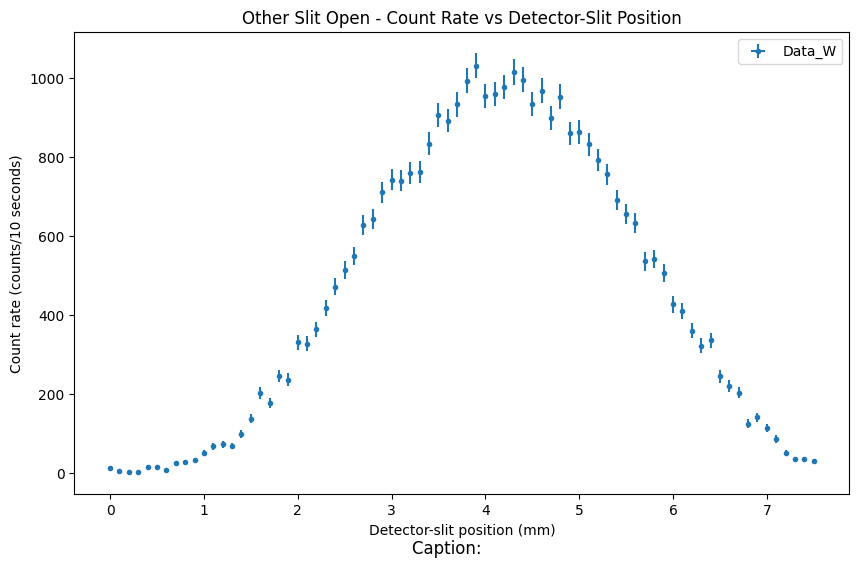

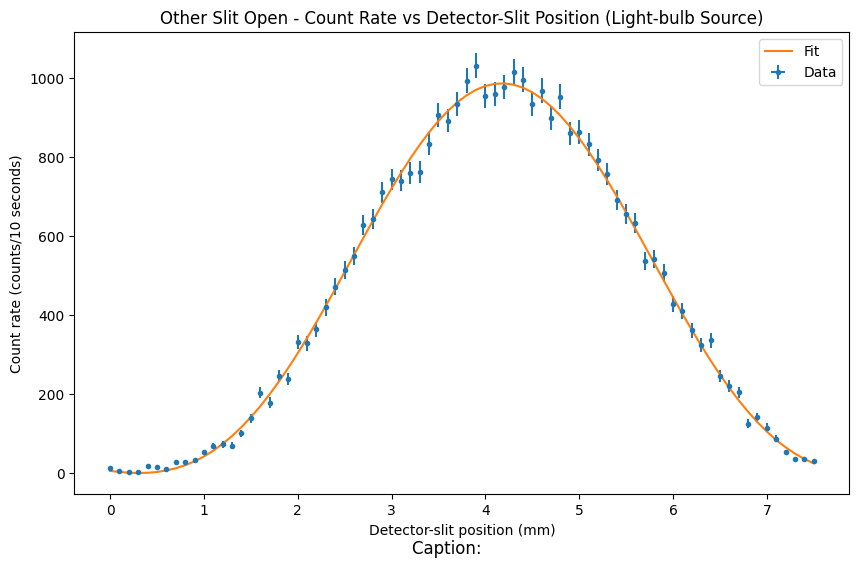

In [30]:
#KEY REMOVE FOR STUDENTS
#Import "OtherSlitOpenPhoton.txt"
data = genfromtxt("OtherSlitOpenPhoton.txt", delimiter=' ', skip_header=0)

# Convert micrometer readings to mm after loading data with genfromtxt and delimiter=' '
# Column 0 = rotation, Column 1 = marks

rotation = data[:, 0]  # in 0.50 mm units
marks = data[:, 1]  # in 0.01 mm units

x_mm = (rotation * 0.50) + (marks * 0.01)  
count_rate = data[:, 2] - 144
x_mm_error = 0.005
count_rate_error = np.sqrt(np.abs(data[:, 2] - 144))


#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(x_mm, count_rate, xerr = x_mm_error, yerr = count_rate_error, fmt='.', label="Data_W")
plt.legend()
plt.xlabel('Detector-slit position (mm)')
plt.ylabel('Count rate (counts/10 seconds)')
plt.title('Other Slit Open - Count Rate vs Detector-Slit Position')
plt.figtext(0.5, 0.01, "Caption: ", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Fraunhofer(x, I0, A, xc):
    I = I0 * (np.sinc((A * (x - xc)) / np.pi))**2
    return I

#Preliminarily Fit the Data
guess_I0 = 1000
guess_A = 2
guess_xc = 6.5

guess=np.array([guess_I0, guess_A, guess_xc])
count_rate = np.nan_to_num(count_rate, nan=0.0) #
uw_fits,uw_covs=curve_fit(Fraunhofer, x_mm, count_rate, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dI/dx
I0, A, xc = uw_fits
with np.errstate(divide='ignore', invalid='ignore'):
    dI_dx = ((2 * I0 * A) / ((A * (x_mm - xc))**3)) * np.sin(A * (x_mm - xc)) * ((A * (x_mm - xc) * np.cos(A * (x_mm - xc)) - np.sin(A * (x_mm - xc))))
    dI_dx = np.nan_to_num(dI_dx, nan=0.0, posinf=0.0, neginf=0.0)

#Calculate total error
sigmas= np.sqrt(count_rate_error**2 + (dI_dx * x_mm_error)**2)

sigmas = np.nan_to_num(sigmas, nan=1.0, posinf=1.0, neginf=1.0) # Ensure sigmas has no zeros, NaNs, or Infs

#Perform weighted fit
fits, covs=curve_fit(Fraunhofer, x_mm, count_rate, p0=guess, sigma=sigmas, maxfev=10000)
stds=np.sqrt(np.diag(covs))


#Calculate reduced chi squared
Red_chi_sq_I1= 1.0/(x_mm.size-3.0) * np.sum((count_rate - Fraunhofer(x_mm, *fits))**2/sigmas**2)
print(f'Reduced Chi Squared = {Red_chi_sq_I1:.3f}')
print(f"I0 = {fits[0]:.3f} ± {stds[0]:.3f}")
print(f"A = {fits[1]:.3f} ± {stds[1]:.3f}")
print(f"xc = {fits[2]:.3f} ± {stds[2]:.3f}")
                 

#Plot the fit with the data!
fit_count_rate = Fraunhofer(x_mm, *fits)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(x_mm, count_rate, xerr=x_mm_error, yerr=count_rate_error, fmt='.', label="Data")
plt.plot(x_mm, fit_count_rate, '-', label="Fit")
plt.legend()
plt.xlabel('Detector-slit position (mm)')
plt.ylabel('Count rate (counts/10 seconds)')
plt.title('Other Slit Open - Count Rate vs Detector-Slit Position (Light-bulb Source)')
plt.figtext(0.5, 0.01, "Caption: ", wrap=True, horizontalalignment='center', fontsize=12)


### Both Slits

Reduced Chi Squared = 51.127
I0 = 3606.675 ± 119.725
A = 0.784 ± 0.016
B = 4.586 ± 0.016
xc = 3.693 ± 0.005


Text(0.5, 0.01, 'Caption: ')

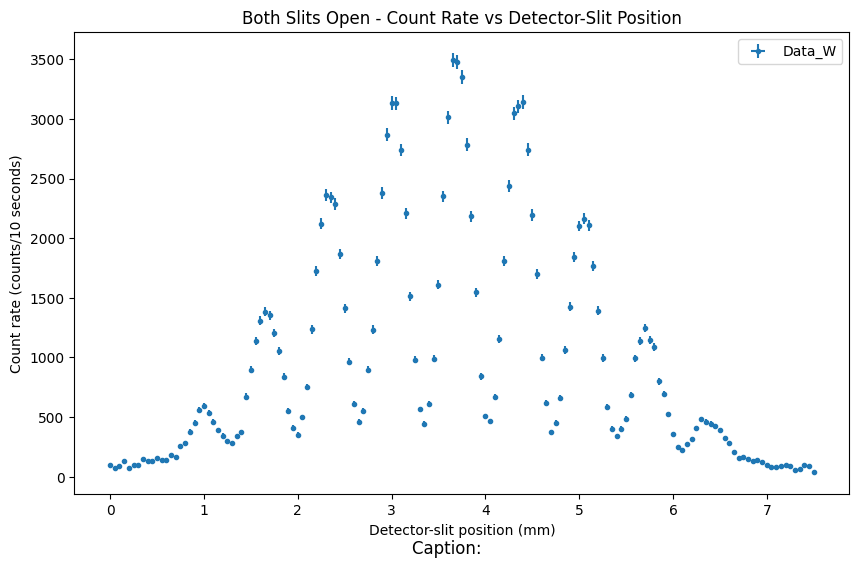

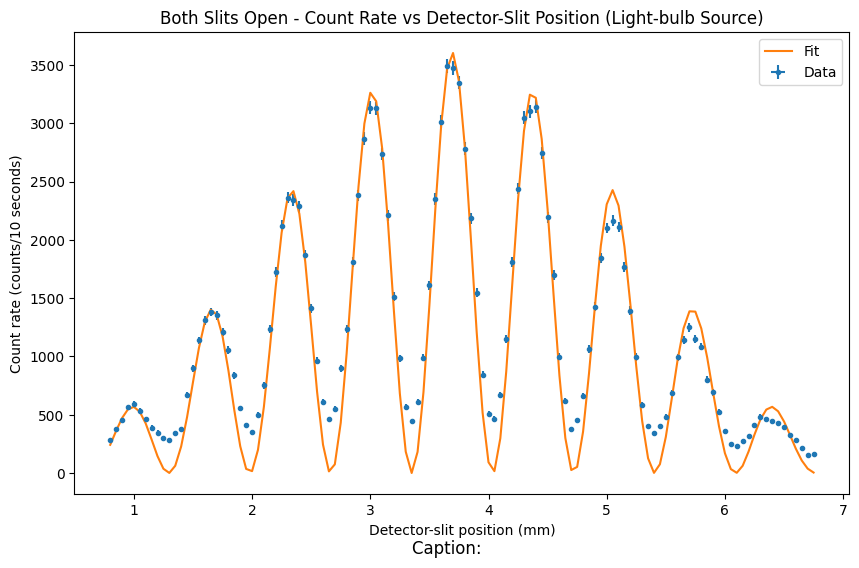

In [9]:
#KEY REMOVE FOR STUDENTS
#Import "BothSlitsOpenPhoton.txt"
data = genfromtxt("BothSlitsOpenPhoton.txt", delimiter=' ', skip_header=1)

# Convert micrometer readings to mm after loading data with genfromtxt and delimiter=' '
# Column 0 = rotation, Column 1 = marks

rotation = data[:, 0]  # in 0.50 mm units
marks = data[:, 1]  # in 0.01 mm units

x_mm = (rotation * 0.50) + (marks * 0.01)  
count_rate = data[:, 2] - 134
x_mm_error = [0.005 for _ in x_mm]
count_rate_error = np.sqrt(data[:, 2] - 134)

x_mm_range = x_mm[16:136]
count_rate_range = count_rate[16:136]
x_mm_error_range = x_mm_error[16:136]
count_rate_error_range = count_rate_error[16:136]


#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(x_mm, count_rate, xerr = x_mm_error, yerr = count_rate_error, fmt='.', label="Data_W")
plt.legend()
plt.xlabel('Detector-slit position (mm)')
plt.ylabel('Count rate (counts/10 seconds)')
plt.title('Both Slits Open - Count Rate vs Detector-Slit Position')
plt.figtext(0.5, 0.01, "Caption: ", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Fraunhofer(x, I0, A, B, xc):
    epsilon = 1e-12
    I = I0 * (np.sin(A * (x - xc + epsilon)) / (A * (x - xc + epsilon)))**2 * (np.cos(B * (x - xc + epsilon)))**2
    return I

#Preliminarily Fit the Data
guess_I0 = 3500
guess_A = 0.5
guess_B = 4
guess_xc = 3.75

epsilon = 1e-12

guess=np.array([guess_I0, guess_A, guess_B, guess_xc])
uw_fits,uw_covs=curve_fit(Fraunhofer, x_mm_range, count_rate_range, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dI/dx
I0, A, B, xc = uw_fits
with np.errstate(divide='ignore', invalid='ignore'):
    dI_dx = (2 * I0 * np.sin(A * (x_mm_range - xc + epsilon)) * np.cos(B * (x_mm_range - xc + epsilon))) / (A**2 * (x_mm_range - xc + epsilon)**3) * (A * (x_mm_range - xc + epsilon) * np.cos(A * (x_mm_range - xc + epsilon)) * np.cos(B * (x_mm_range - xc + epsilon)) - B * (x_mm_range - xc + epsilon) * np.sin(A * (x_mm_range - xc + epsilon)) * np.sin(B * (x_mm_range - xc + epsilon)) - np.sin(A * (x_mm_range - xc + epsilon)) * np.cos(B * (x_mm_range - xc + epsilon)))
    dI_dx = np.nan_to_num(dI_dx, nan=0.0, posinf=0.0, neginf=0.0)

#Calculate total error
sigmas= np.sqrt(count_rate_error_range**2 + (dI_dx * x_mm_error_range)**2)

sigmas = np.nan_to_num(sigmas, nan=1.0, posinf=1.0, neginf=1.0) # Ensure sigmas has no zeros, NaNs, or Infs

#Perform weighted fit
fits, covs=curve_fit(Fraunhofer, x_mm_range, count_rate_range, p0=guess, sigma=sigmas, maxfev=10000)
stds=np.sqrt(np.diag(covs))


#Calculate reduced chi squared
Red_chi_sq= 1.0/(x_mm_range.size-4.0) * np.sum((count_rate_range - Fraunhofer(x_mm_range, *fits))**2/sigmas**2)
print(f'Reduced Chi Squared = {Red_chi_sq:.3f}')
print(f"I0 = {fits[0]:.3f} ± {stds[0]:.3f}")
print(f"A = {fits[1]:.3f} ± {stds[1]:.3f}")
print(f"B = {fits[2]:.3f} ± {stds[2]:.3f}")
print(f"xc = {fits[3]:.3f} ± {stds[3]:.3f}")

                 

#Plot the fit with the data!
fit_count_rate = Fraunhofer(x_mm_range, *fits)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(x_mm_range, count_rate_range, xerr=x_mm_error_range, yerr=count_rate_error_range, fmt='.', label="Data")
plt.plot(x_mm_range, fit_count_rate, '-', label="Fit")
plt.legend()
plt.xlabel('Detector-slit position (mm)')
plt.ylabel('Count rate (counts/10 seconds)')
plt.title('Both Slits Open - Count Rate vs Detector-Slit Position (Light-bulb Source)')
plt.figtext(0.5, 0.01, "Caption: ", wrap=True, horizontalalignment='center', fontsize=12)


### Estimate the probability of measuring one photon in the apparatus

In [12]:
from scipy.integrate import quad

area, error = quad(Fraunhofer, x_mm_range[0], x_mm_range[-1], args=tuple(fits))
print(f"Area under the curve: {area:.3f} ± {error:.3}")

count_rate = area / 10
print(f"Count rate: {count_rate:.3f} counts/second")

L = 1 # distance from slit to detector in meters
c = 3e8 # speed of light in m/s
flight_time = L / c # in seconds
probability_of_detection = flight_time / (0.04 / count_rate)
print(f"Probability of detecting one photon: {probability_of_detection:.3e}")

Area under the curve: 6438.689 ± 5.34e-05
Count rate: 643.869 counts/second
Probability of detecting one photon: 5.366e-05
